In [177]:
import pandas as pd

df = pd.read_csv('data/NYC.csv')

# sampling biar ringan
df = df.sample(n=450000, random_state=42)

print(df.head())
print(df.info())
print(df.describe())

                id  vendor_id      pickup_datetime     dropoff_datetime  \
67250    id2793718          2  2016-06-08 07:36:19  2016-06-08 07:53:39   
1397036  id3485529          2  2016-04-03 12:58:11  2016-04-03 13:11:58   
1021087  id1816614          2  2016-06-05 02:49:13  2016-06-05 02:59:27   
951424   id1050851          2  2016-05-05 17:18:27  2016-05-05 17:32:54   
707882   id0140657          1  2016-05-12 17:43:38  2016-05-12 19:06:25   

         passenger_count  pickup_longitude  pickup_latitude  \
67250                  1           -73.986           40.736   
1397036                1           -73.978           40.764   
1021087                5           -73.989           40.744   
951424                 2           -73.990           40.731   
707882                 4           -73.789           40.647   

         dropoff_longitude  dropoff_latitude store_and_fwd_flag  trip_duration  
67250              -73.980            40.760                  N           1040  
1397036 

In [178]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df = df.dropna(subset=['pickup_datetime'])

df = df.set_index('pickup_datetime')

# demand per jam
demand = df.resample('h').size().reset_index(name='demand')

In [179]:
demand['hour'] = demand['pickup_datetime'].dt.hour
demand['day'] = demand['pickup_datetime'].dt.day
demand['month'] = demand['pickup_datetime'].dt.month
demand['day_of_week'] = demand['pickup_datetime'].dt.dayofweek
demand['lag_1'] = demand['demand'].shift(1)
demand['lag_2'] = demand['demand'].shift(2)
demand['lag_3'] = demand['demand'].shift(3)

demand = demand.dropna()

print(demand.isnull().sum())

pickup_datetime    0
demand             0
hour               0
day                0
month              0
day_of_week        0
lag_1              0
lag_2              0
lag_3              0
dtype: int64


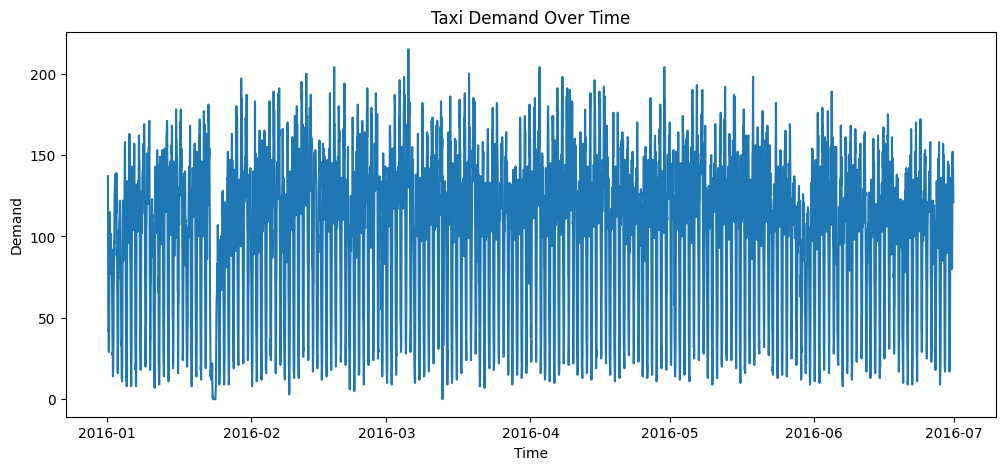

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(demand['pickup_datetime'], demand['demand'])
plt.title("Taxi Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()

In [181]:
X = demand[['hour', 'day', 'month', 'day_of_week', 'lag_1', 'lag_2', 'lag_3']]
y = demand['demand']

In [182]:
from sklearn.model_selection import train_test_split

# 70:30
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.3, random_state=42)

# 80:20
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

# 90:10
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.1, random_state=42)

In [183]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"=== {name} ===")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print()

    return r2

In [184]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# ===============================
# SPLIT 70:30
# ===============================
print("=== SPLIT 70:30 ===\n")

evaluate_model(
    "XGBoost",
    XGBRegressor(n_estimators=200, max_depth=6),
    X_train1, X_test1, y_train1, y_test1
)

evaluate_model(
    "LightGBM",
    LGBMRegressor(n_estimators=30, max_depth=2, verbose=-1),
    X_train1, X_test1, y_train1, y_test1
)

evaluate_model(
    "CatBoost",
    CatBoostRegressor(iterations=20, depth=2, verbose=0),
    X_train1, X_test1, y_train1, y_test1
)


# ===============================
# SPLIT 80:20
# ===============================
print("=== SPLIT 80:20 ===\n")

r2_xgb = evaluate_model(
    "XGBoost",
    XGBRegressor(n_estimators=200, max_depth=6),
    X_train2, X_test2, y_train2, y_test2
)

r2_lgbm = evaluate_model(
    "LightGBM",
    LGBMRegressor(n_estimators=30, max_depth=2, verbose=-1),
    X_train2, X_test2, y_train2, y_test2
)

r2_cat = evaluate_model(
    "CatBoost",
    CatBoostRegressor(iterations=20, depth=2, verbose=0),
    X_train2, X_test2, y_train2, y_test2
)


# ===============================
# SPLIT 90:10
# ===============================
print("=== SPLIT 90:10 ===\n")

evaluate_model(
    "XGBoost",
    XGBRegressor(n_estimators=200, max_depth=6),
    X_train3, X_test3, y_train3, y_test3
)

evaluate_model(
    "LightGBM",
    LGBMRegressor(n_estimators=30, max_depth=2, verbose=-1),
    X_train3, X_test3, y_train3, y_test3
)

evaluate_model(
    "CatBoost",
    CatBoostRegressor(iterations=20, depth=2, verbose=0),
    X_train3, X_test3, y_train3, y_test3
);

=== SPLIT 70:30 ===

=== XGBoost ===
MAE : 11.215086936950684
RMSE: 15.032450352441973
R2  : 0.900331974029541

=== LightGBM ===
MAE : 13.970395508752615
RMSE: 18.3623303796336
R2  : 0.8512859931397593

=== CatBoost ===
MAE : 12.761001078287434
RMSE: 16.86713587484615
R2  : 0.8745187119813069

=== SPLIT 80:20 ===

=== XGBoost ===
MAE : 11.043150901794434
RMSE: 14.763715154264187
R2  : 0.9063625335693359

=== LightGBM ===
MAE : 14.010372173976677
RMSE: 18.4531480092793
R2  : 0.8537151767044282

=== CatBoost ===
MAE : 12.44881222927674
RMSE: 16.39231907679735
R2  : 0.8845645662411356

=== SPLIT 90:10 ===

=== XGBoost ===
MAE : 11.023430824279785
RMSE: 15.18172693614504
R2  : 0.9019675850868225

=== LightGBM ===
MAE : 13.649386676560312
RMSE: 18.38307642466428
R2  : 0.8562645794800607

=== CatBoost ===
MAE : 12.681729643750627
RMSE: 17.130781923589062
R2  : 0.8751806859664087



In [185]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=3)
grid.fit(X_train2, y_train2)

best_xgb = grid.best_estimator_

print("Best Parameter:", grid.best_params_)

Best Parameter: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}


In [188]:
r2_xgb = evaluate_model(
    "XGBoost Tuned",
    best_xgb,
    X_train2, X_test2, y_train2, y_test2
);

=== XGBoost Tuned ===
MAE : 10.15498161315918
RMSE: 13.532854015963625
R2  : 0.9213249087333679



In [187]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'R2 Score': [r2_xgb, r2_lgbm, r2_cat]
})

print(results)

      Model  R2 Score
0   XGBoost     0.921
1  LightGBM     0.854
2  CatBoost     0.885
